In [1]:
#--------------------TRAIN     TEST    SET -----------------------------

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

(150, 4)


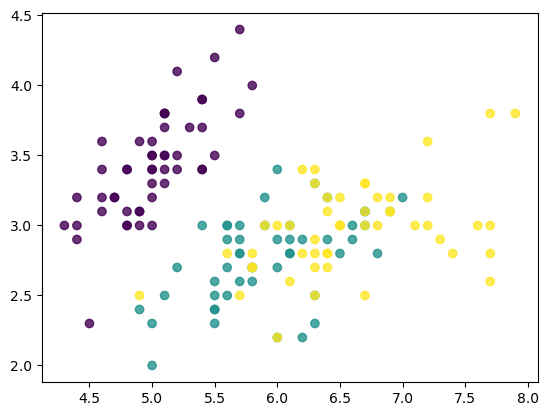

In [47]:
iris = load_iris()

x = iris.data
y = iris.target

print(x.shape)
plt.scatter(x[:, 0], x[:, 1], c=y, alpha=0.8)

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 5)     #diviser les données en des tableaux  avec 20% des données dans le test

In [50]:
print('Train set:', x_train.shape)
print('Test set:', x_test.shape)

Train set: (120, 4)
Test set: (30, 4)


Text(0.5, 1.0, 'Test set')

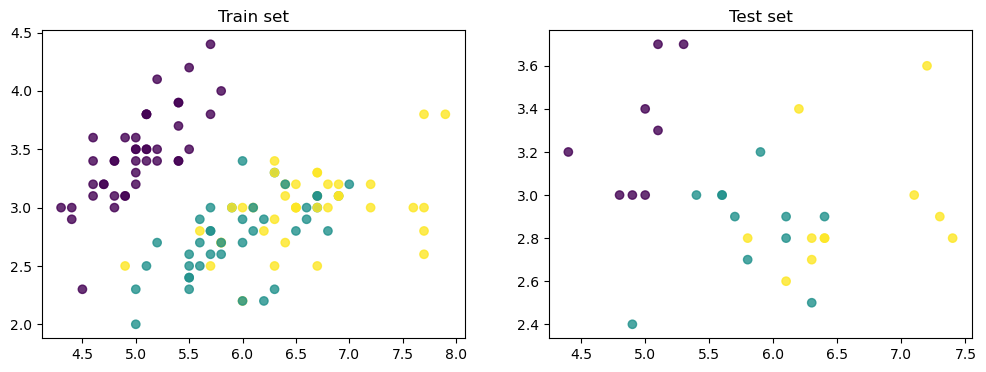

In [51]:
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, alpha=0.8)
plt.title('Train set')
plt.subplot(122)
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, alpha=0.8)
plt.title('Test set')

In [60]:
from sklearn.neighbors import KNeighborsClassifier

In [61]:
model = KNeighborsClassifier(n_neighbors=1)

model.fit(x_train, y_train)
print('Train set:' , model.score(x_train, y_train))
print('Test  set:' , model.score(x_test, y_test))

Train set: 1.0
Test  set: 0.9


In [62]:
#-----------------------------------------validation 

In [63]:
#----------------------------------     CREATION DU VAL SET POUR EVALUER LE MODELE

In [64]:
#---------------------------------  CROSSS VALIDATION 

In [65]:
from sklearn.model_selection import cross_val_score

In [66]:
cross_val_score(KNeighborsClassifier(), x_train, y_train, cv=5, scoring='accuracy')    # 5 score ,  le mettrique : accuracy

array([1.        , 1.        , 1.        , 0.95833333, 0.95833333])

In [67]:
cross_val_score(KNeighborsClassifier(10), x_train, y_train, cv=5, scoring='accuracy').mean()

np.float64(0.975)

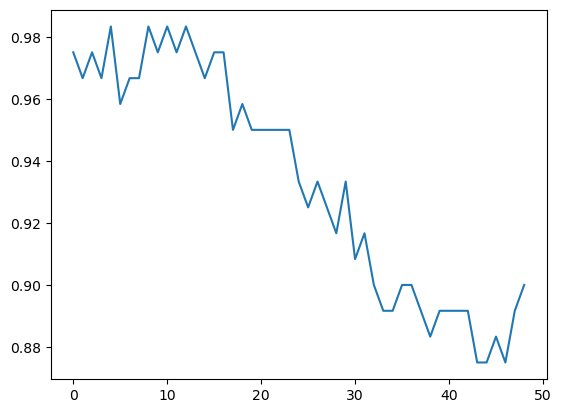

In [68]:
val_score = []

for k in range(1, 50):
    score = cross_val_score(KNeighborsClassifier(k), x_train, y_train, cv=5, scoring='accuracy').mean()
    val_score.append(score)

plt.plot(val_score)


In [69]:
#_-------------____________   LA FONCTION VALIDATION CURVE  ___________________-------------------

In [70]:
from sklearn.model_selection import validation_curve

In [74]:
'''
model = KNeighborsClassifier()
k = np.arange(1, 50)

train_score, val_score = validation_curve(model, x_train, y_train, 'n_neighbors', k, cv=5)

plt.plot(k, val_score.mean(axis =1)) '''


"\nmodel = KNeighborsClassifier()\nk = np.arange(1, 50)\n\ntrain_score, val_score = validation_curve(model, x_train, y_train, 'n_neighbors', k, cv=5)\n\nplt.plot(k, val_score.mean(axis =1)) "

In [75]:
#--------------------------------------- GRIDSearchCV  ---------------------

In [76]:
from sklearn.model_selection import GridSearchCV

In [77]:
param_grid = {'n_neighbors': np.arange(1, 20),
              'metric':['euclidean', 'manhattan']}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)

grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19])})

In [78]:
grid.best_score_

np.float64(0.9833333333333334)

In [79]:
grid.best_params_

{'metric': 'euclidean', 'n_neighbors': np.int64(5)}

In [80]:
model = grid.best_estimator_

In [81]:
model.score(x_test, y_test)

0.9333333333333333

In [82]:
#---------------------------------------------- LE METRIX 

In [83]:
from sklearn.metrics import confusion_matrix

In [84]:
confusion_matrix(y_test, model.predict(x_test))

array([[ 8,  0,  0],
       [ 0,  9,  2],
       [ 0,  0, 11]])

In [85]:
#_________________________    COURBE DES PERFORMANCE 

In [86]:
from sklearn.model_selection import learning_curve

[ 9 19 28 38 48 57 67 76 86 96]


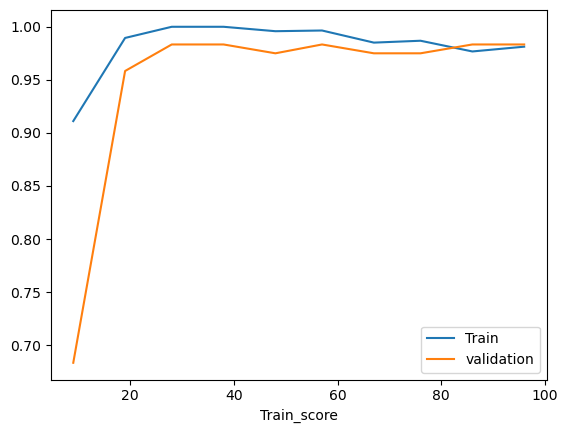

In [91]:
N, train_score, val_score = learning_curve(model, x_train,y_train, train_sizes = np.linspace(0.1, 1.0, 10), cv=5)
print(N)


plt.plot(N, train_score.mean(axis=1), label='Train')
plt.plot(N, val_score.mean(axis=1), label='validation')
plt.xlabel('Train_score')
plt.legend()